# Importing Libraries

In [2]:
import sys, os
sys.path.append(os.pardir)
sys.path.append('./')
import numpy as np
import matplotlib.pyplot as plt

import cv2
import skimage.transform as sktrans
import skimage.filters as skfilt

#Import tensorflow & tf.keras library
import tensorflow as tf
from tensorflow import keras

from WB_TSX import read_pickle, multiclass_sparse_weighted_cross_entropy, DataGenerator,get_unet


#  Importing Data

In [3]:
my_path = "/workspace/pytorch_unet/python-programs/Tensor/02_IITP/"  # 경로 설정

key_sat = "TSX" 
#loading dataset
data = read_pickle(my_path + "/TSX_ai_data.pkl") # data for training a model
 
x_train = np.array(data[key_sat]["train"]["image"])
t_train = np.array(data[key_sat]["train"]["label"])

x_test = np.array(data[key_sat]["test"]["image"])
t_test = np.array(data[key_sat]["test"]["label"])

N_train = x_train.shape[0]
N_test  = x_test.shape[0]
t_train = t_train.astype('uint8')
t_test = t_test.astype('uint8')
#printing the shapes of the vectors
print('shape of training data:  ' + str(x_train.shape))
print('shape of training label: ' + str(t_train.shape))
print('shape of test data:     '  + str(x_test.shape))
print('shape of test label:    '  + str(t_test.shape))

shape of training data:  (1117, 512, 512, 1)
shape of training label: (1117, 512, 512)
shape of test data:     (309, 512, 512, 1)
shape of test label:    (309, 512, 512)


In [4]:
B,N,M =t_test.shape
wratio = np.sum(t_test==1)/(B*N*M)
print(f"레이블 데이터에서 물과 물이 아닌 픽셀의 비 {wratio}")


레이블 데이터에서 물과 물이 아닌 픽셀의 비 0.11936581559165782


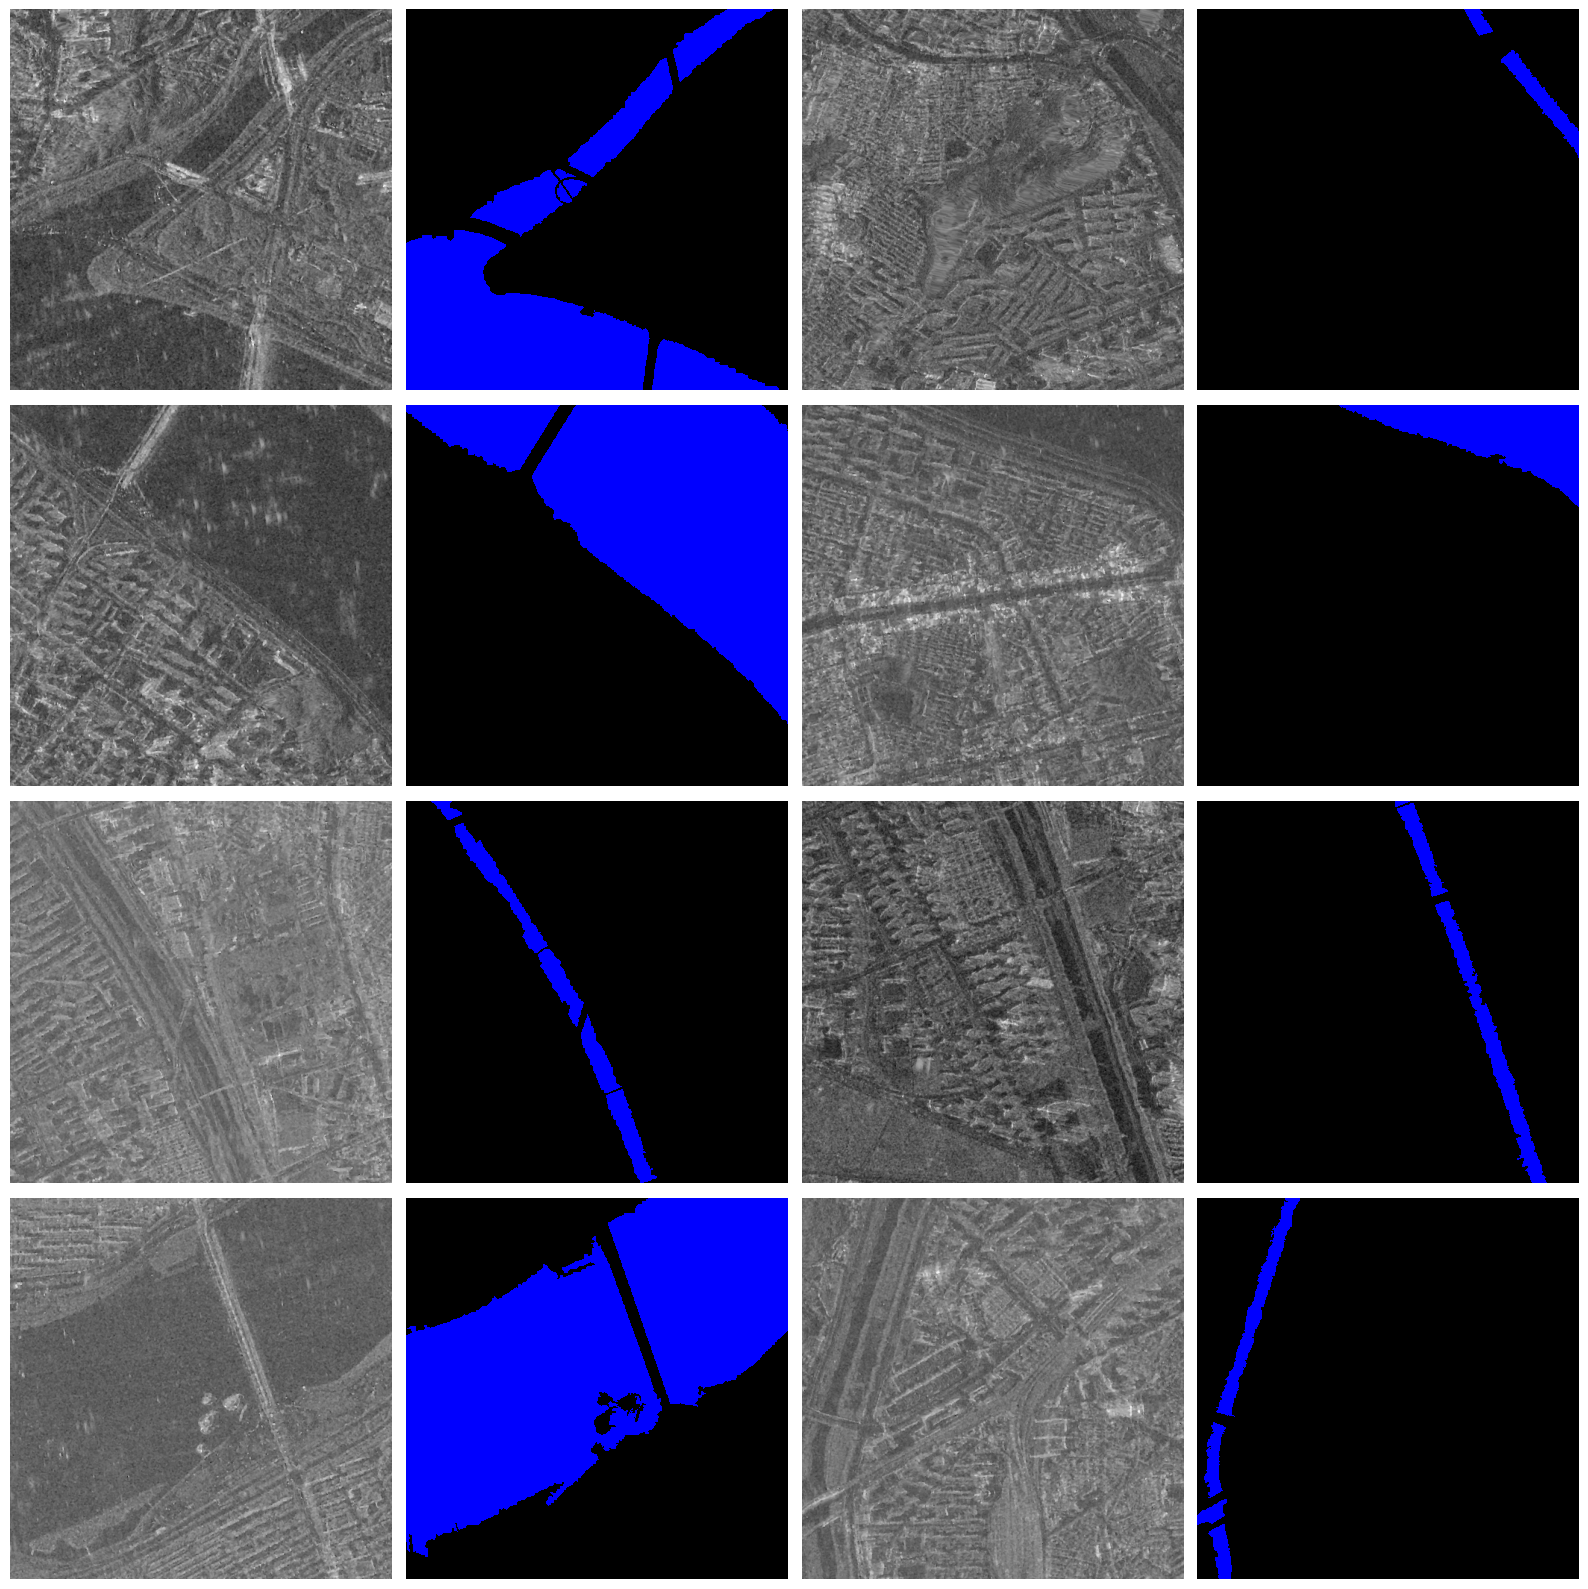

In [5]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# 컬러맵 정의
cmap = ListedColormap(['black', 'blue'])

plt.figure(figsize=(16, 16))

# 4x4 시각화를 위한 인덱스 배열 생성
random_indices = np.random.choice(x_train.shape[0], size=8, replace=False)  # 8개의 랜덤 인덱스 생성 (한 행당 2개씩)

for i in range(4):  # 4행
    for j in range(4):  # 4열
        idx = i * 2 + j // 2  # 같은 행에서 짝수 열과 홀수 열이 동일한 인덱스를 공유
        plt.subplot(4, 4, i * 4 + j + 1)  # 4행 4열 서브플롯 설정
        if j % 2 == 0:
            plt.imshow(x_train[random_indices[idx]], cmap='gray')  # x_train 이미지 시각화
        else:
            plt.imshow(t_train[random_indices[idx]], cmap=cmap)  # t_train 클래스 시각화
        plt.axis('off')  # 축 제거

plt.tight_layout()
plt.show()


# Setting up Model Hyperparameters & Training UNet

In [6]:
# setup model hyperparameters
lr = 0.0001
mini_batch=10
preTrained = False
param_file = my_path + "/checkpoint/TSX_Unet_Commit.h5"
class_weights = [0.15,0.85]

In [7]:
mirrored_strategy = tf.distribute.MirroredStrategy(devices=["/gpu:0","/gpu:1","/gpu:2"])
with mirrored_strategy.scope():
    model  = get_unet(input_size=(x_train.shape[1],x_train.shape[2],x_train.shape[3]),outputsize=2,nfilters=[64, 128, 256, 512])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr) ,loss=multiclass_sparse_weighted_cross_entropy(class_weights=class_weights), metrics='accuracy')
model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2')


2025-01-13 07:43:50.705020: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22272 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:1a:00.0, compute capability: 8.9
2025-01-13 07:43:50.705482: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22272 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:67:00.0, compute capability: 8.9
2025-01-13 07:43:50.705887: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 21584 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:68:00.0, compute capability: 8.9


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [8]:
if preTrained:
    model.load_weights(param_file)

train_gen = DataGenerator(images=x_train, labels=t_train, batch_size=mini_batch, shuffle=True)
test_gen  = DataGenerator(images=x_test,  labels=t_test,  batch_size=mini_batch, shuffle=True)

In [9]:
# Training
mcp_save = keras.callbacks.ModelCheckpoint(param_file, save_best_only=True, monitor='val_loss', mode='auto', save_weights_only=True)
earlyStopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=1000, verbose=0, mode='auto')
reduce_lr_loss = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=100, verbose=0, min_delta=1e-2, mode='auto')


hist = model.fit(train_gen,validation_data= test_gen, epochs=500, callbacks=[earlyStopping, mcp_save, reduce_lr_loss])

Epoch 1/500
INFO:tensorflow:Collective all_reduce tensors: 114 all_reduces, num_devices = 3, group_size = 3, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 114 all_reduces, num_devices = 3, group_size = 3, implementation = CommunicationImplementation.NCCL, num_packs = 1


2025-01-10 08:59:20.444896: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-01-10 08:59:20.470869: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-01-10 08:59:20.499144: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-01-10 08:59:28.670648: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f6a87b62060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-10 08:59:28.670698: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-01-10 08:59:28.670710: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-01-10 08:59:28.670719: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA GeForce RTX 4090, Compute Cap

111/111 [==============================] - 70s 315ms/step - loss: 0.0469 - accuracy: 0.8103 - val_loss: 0.0922 - val_accuracy: 0.1188 - lr: 1.0000e-04
Epoch 2/500
111/111 [==============================] - 33s 295ms/step - loss: 0.0252 - accuracy: 0.9386 - val_loss: 0.0623 - val_accuracy: 0.9211 - lr: 1.0000e-04
Epoch 3/500
111/111 [==============================] - 33s 295ms/step - loss: 0.0208 - accuracy: 0.9510 - val_loss: 0.0275 - val_accuracy: 0.9295 - lr: 1.0000e-04
Epoch 4/500
111/111 [==============================] - 33s 295ms/step - loss: 0.0187 - accuracy: 0.9567 - val_loss: 0.0224 - val_accuracy: 0.9236 - lr: 1.0000e-04
Epoch 5/500
111/111 [==============================] - 33s 299ms/step - loss: 0.0153 - accuracy: 0.9652 - val_loss: 0.0137 - val_accuracy: 0.9574 - lr: 1.0000e-04
Epoch 6/500
111/111 [==============================] - 32s 286ms/step - loss: 0.0146 - accuracy: 0.9656 - val_loss: 0.0143 - val_accuracy: 0.9608 - lr: 1.0000e-04
Epoch 7/500
111/111 [=============

In [ ]:
import pickle
with open(my_path+'/TSX_Unet_commit.pickle', 'wb') as f:
    pickle.dump(hist.history, f, pickle.HIGHEST_PROTOCOL)  

In [11]:
import pickle
with open(my_path+'/TSX_Unet_commit.pickle',"rb") as fr:
    hist = pickle.load(fr)

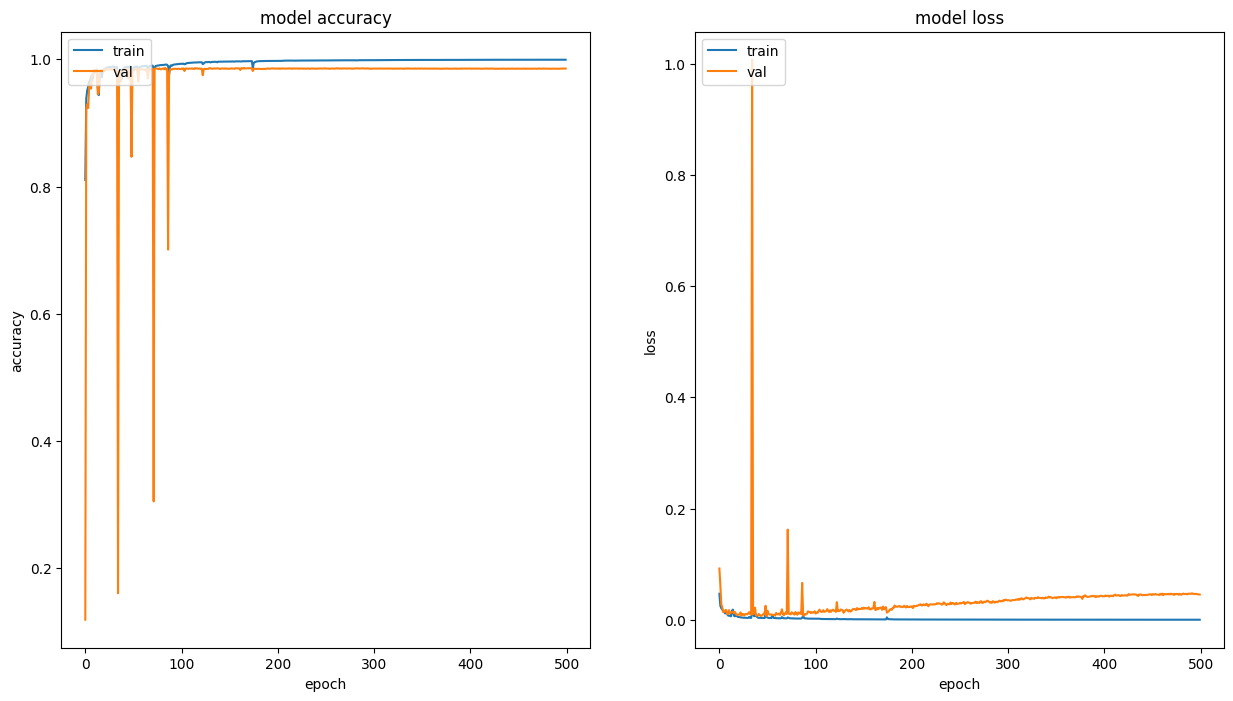

In [12]:
# figures from w aug
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.plot(hist['accuracy'])
plt.plot(hist['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1,2,2)
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.show()

In [8]:
model.load_weights(param_file)